# DNA Walker Project
<em>Tse Kam Pui | Supervisor: Wang Zhisong | Co-Supervisor: Duane Loh</em><br>
Repository: [MachineLearning_for_DNAwalker](https://github.com/GBGBGB780/MachineLearning_for_DNAwalker.git)

## Overview
This notebook focuses on dataset inspection, preprocessing diagnostics, and model-related visualizations for the DNA walker inverse-design project.

## Workflow
Step 1: parameter sampling and simulation. Step 2: data preprocessing and visualization. Step 3: model architecture snapshots.

## Step 1: Parameter Sampling
Sample 7 hidden physical parameters before running the kinetic simulation pipeline.

### Parameter Ranges
Sampling bounds used for the 7 trainable physical parameters.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import qmc
import pandas as pd
import seaborn as sns
import time
import os

try:
    import umap
except ImportError:
    umap = None
    print("UMAP is not installed; the notebook will fall back to PCA for embedding plots.")

# Configuration for plots
plt.style.use('seaborn-v0_8-whitegrid')

# Define parameter names
param_names = [
    'E_b', 'E_b_azo_trans', 'E_b_azo_cis',
    'k_mig', 'k0', 'drt_z', 'drt_s'
]

# Define bounds (Min, Max) based on configfile.ini
bounds = np.array([
    [-2.0, -0.5],    # E_b
    [-2.0, -0.5],    # E_b_azo_trans
    [-1.0, -0.001],  # E_b_azo_cis
    [0.01, 1.0],     # k_mig
    [1e-6, 1e-4],    # k0
    [0.001, 1.0],    # drt_z
    [0.001, 1.0]     # drt_s
])

print(f"Total Parameters to sample: {len(param_names)}")
for name, bound in zip(param_names, bounds):
    print(f"{name:>15}: [{bound[0]:>3}, {bound[1]:>3}]")

C:\Users\GB\AppData\Roaming\Python\Python311\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\GB\AppData\Roaming\Python\Python311\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


Total Parameters to sample: 7
            E_b: [-2.0, -0.5]
  E_b_azo_trans: [-2.0, -0.5]
    E_b_azo_cis: [-1.0, -0.001]
          k_mig: [0.01, 1.0]
             k0: [1e-06, 0.0001]
          drt_z: [0.001, 1.0]
          drt_s: [0.001, 1.0]


### Latin Hypercube Sampling
LHS is used here as a space-filling strategy over the 7D parameter space.

In [2]:
num_samples = 10000

# Initialize LHS sampler
sampler = qmc.LatinHypercube(d=len(param_names), seed=42)

# Generate samples in [0, 1] range
sample_normalized = sampler.random(n=num_samples)

# Scale samples to physical bounds
# Formula: Y = min + (max - min) * sample_norm
lower_bounds = bounds[:, 0]
upper_bounds = bounds[:, 1]
Y_phys = qmc.scale(sample_normalized, lower_bounds, upper_bounds)

# Convert to DataFrame for visualization
df_params = pd.DataFrame(Y_phys, columns=param_names)
print(f"Generated shape: {df_params.shape}")
df_params.head()

Generated shape: (10000, 7)


,E_b,E_b_azo_trans,E_b_azo_cis,k_mig,k0,drt_z,drt_s
0,-0.769216,-1.085966,-0.199687,0.883111,0.000027,0.367635,0.325099
1,-1.588518,-0.815619,-0.914131,0.046197,0.000007,0.621015,0.133985
2,-0.508617,-1.764234,-0.350606,0.428467,0.000028,0.617120,0.474151
3,-1.149553,-1.548046,-0.481608,0.121892,0.000071,0.926527,0.067829
4,-1.375123,-0.984602,-0.693681,0.912586,0.000043,0.123840,0.688864


### Sampling Check
The plots below show marginal coverage of the sampled parameters.

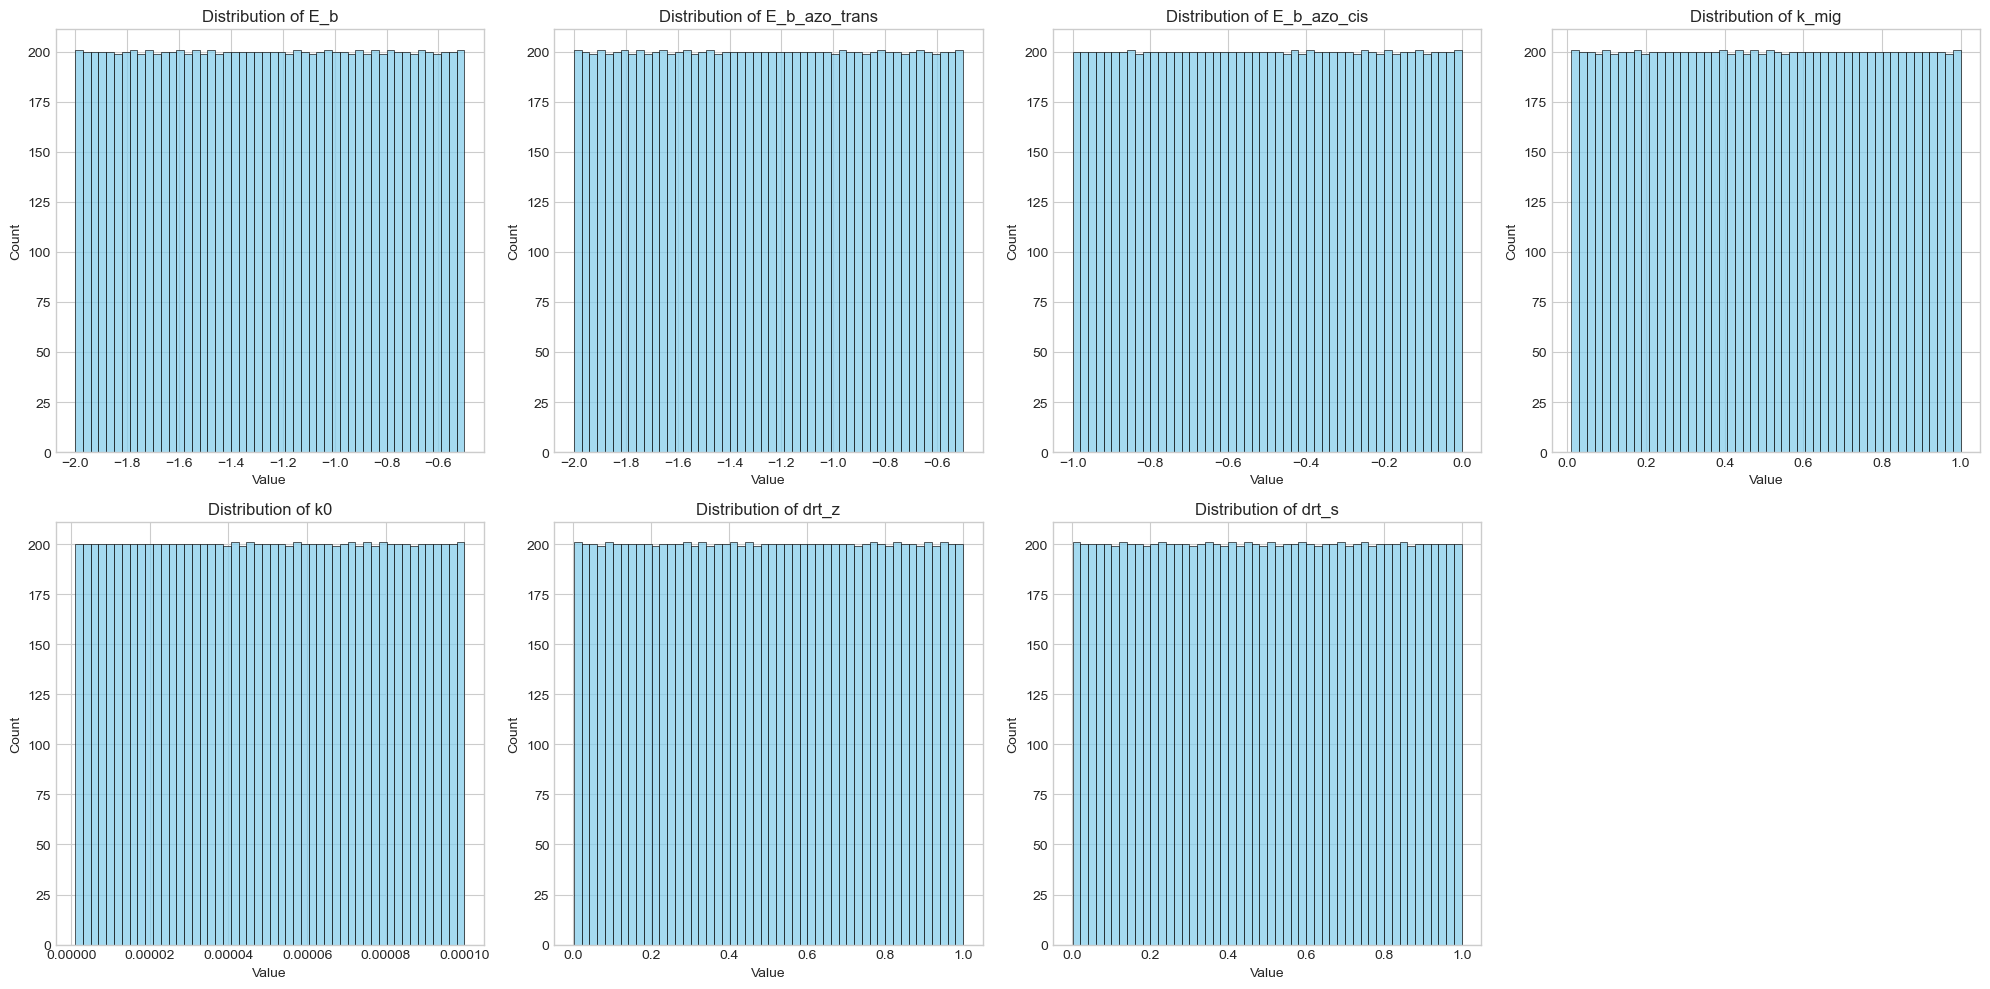

In [3]:
# Visualize the distributions
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(param_names):
    sns.histplot(df_params[col], bins=50, ax=axes[i], color='skyblue', edgecolor='black')
    axes[i].set_title(f'Distribution of {col}', fontsize=12)
    axes[i].set_ylabel('Count')
    axes[i].set_xlabel('Value')

# Remove empty subplot if any
if len(param_names) < 8:
    fig.delaxes(axes[7])

plt.tight_layout()
plt.show()

The sampled parameters show reasonably even marginal coverage, which is sufficient for downstream simulation and training-data generation.

## Phase 2: Kinetic Simulation
The full production simulator is in MATLAB (`gendata.m`). The code below is only a compact rate-matrix demo for presentation.

In [4]:
kBT = 4.14


def build_rate_matrix_demo(params, energy_configs):
    """
    Compact pedagogical example of a 14x14 rate matrix.

    Convention:
        R[i, j] is the transition rate from state j -> state i,
        so each column should sum to zero to conserve total probability.
    """
    rate_matrix = np.zeros((14, 14), dtype=float)
    k_mig = float(params['k_mig'])

    # Example reversible pair: State 1 <-> State 4
    dE_1_4 = float(energy_configs['t'][0] - energy_configs['t'][3])
    rate_matrix[0, 3] = k_mig
    rate_matrix[3, 0] = k_mig * np.exp(np.clip(dE_1_4 / kBT, -50, 50))

    # Fill the diagonal so each column sums to zero.
    outgoing = rate_matrix.sum(axis=0)
    np.fill_diagonal(rate_matrix, -outgoing)
    return rate_matrix


def solve_master_equation_demo(initial_state, rate_matrix, dt, steps):
    """
    Forward-Euler demonstrator for dP/dt = R P.
    The production data generator uses a more complete MATLAB implementation.
    """
    P = np.asarray(initial_state, dtype=float).copy()
    P = P / P.sum()
    history = [P.copy()]

    for step in range(steps):
        P = P + dt * (rate_matrix @ P)
        P = np.clip(P, 0.0, None)
        P = P / P.sum()
        if (step + 1) % 10 == 0:
            history.append(P.copy())

    return np.vstack(history)


example_params = {'k_mig': 0.1}
example_energies = {'t': np.linspace(-1.2, -0.2, 14)}
R_demo = build_rate_matrix_demo(example_params, example_energies)
P0 = np.zeros(14)
P0[0] = 1.0
history_demo = solve_master_equation_demo(P0, R_demo, dt=0.05, steps=200)

print('Rate matrix shape:', R_demo.shape)
print('Column sums (should be close to 0):', np.round(R_demo.sum(axis=0), 8))
print('History shape:', history_demo.shape)

Rate matrix shape: (14, 14)
Column sums (should be close to 0): [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
History shape: (21, 14)


## Phase 3: From States to Curves
Simulated state probabilities are mapped to the observable FAM, TYE, and CY5 fluorescence curves.

## Step 2: Data Engineering
This section shows the actual repository preprocessing logic and the related diagnostics.

### Preprocessing Notes
CNN uses flattened inputs, while the Transformer keeps the original `(3, 7801)` signal structure. Invalid samples are removed before training.

The notebook uses the full dataset when available, and otherwise falls back to the local smoke dataset so the visual workflow remains runnable.

In [5]:
from pathlib import Path
from IPython.display import display

DATASET_CANDIDATES = [
    Path('./results/training_dataset.npz'),
    Path('./results/training_dataset_smoke.npz'),
]

npz_path = next((path for path in DATASET_CANDIDATES if path.exists()), None)
if npz_path is None:
    raise FileNotFoundError(
        'No dataset was found. Expected one of: '
        + ', '.join(str(path) for path in DATASET_CANDIDATES)
    )

dataset_mode = 'smoke' if 'smoke' in npz_path.name else 'full'
print(f'Using {dataset_mode} dataset: {npz_path}')

with np.load(npz_path) as dataset:
    X_data = dataset['X'].astype(np.float32)
    Y_data = dataset['Y'].astype(np.float32)

print(f'Raw X shape: {X_data.shape}')
print(f'Raw Y shape: {Y_data.shape}')

Using smoke dataset: results\training_dataset_smoke.npz
Raw X shape: (18, 3, 7801)
Raw Y shape: (18, 7)


In [6]:
raw_param_summary = pd.DataFrame(
    {
        'min': Y_data.min(axis=0),
        'max': Y_data.max(axis=0),
        'mean': Y_data.mean(axis=0),
        'std': Y_data.std(axis=0),
    },
    index=param_names,
)

channel_amplitudes = pd.DataFrame(
    X_data.max(axis=2) - X_data.min(axis=2),
    columns=['FAM_amp', 'TYE_amp', 'CY5_amp'],
)

print('Raw parameter summary:')
display(raw_param_summary.round(4))

print('Channel amplitude summary:')
display(channel_amplitudes.describe().T[['min', 'max', 'mean', 'std']].round(4))

Raw parameter summary:


,min,max,mean,std
E_b,-1.9937,-0.6408,-1.2093,0.4212
E_b_azo_trans,-1.9721,-0.7300,-1.3041,0.4590
E_b_azo_cis,-0.4101,0.1520,-0.1447,0.1677
k_mig,0.0572,0.2892,0.1755,0.0724
k0,0.0000,0.0001,0.0000,0.0000
drt_z,0.2333,0.7871,0.4487,0.1460
drt_s,0.0196,0.4670,0.2471,0.1298


Channel amplitude summary:


,min,max,mean,std
FAM_amp,0.0027,0.8399,0.1618,0.2332
TYE_amp,0.0141,0.7452,0.2477,0.2334
CY5_amp,0.0030,0.5077,0.1552,0.1595


In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from config_loader import Config

# Mirror the actual training scripts instead of the earlier simplified notebook version.
parent_config = Config('configfile.ini')
Y_processed = Y_data.copy()

# Selective log-transform for parameters that span orders of magnitude.
for name in parent_config.get_log_transform_params():
    idx = param_names.index(name)
    Y_processed[:, idx] = np.log10(Y_processed[:, idx] + parent_config.get_log_epsilon())

# Optional amplitude filter from the repo config.
channel_amplitudes_np = X_data.max(axis=2) - X_data.min(axis=2)
if parent_config.get_amplitude_filter_enabled():
    amp_thresholds = np.array(parent_config.get_amplitude_thresholds(), dtype=np.float32)
    mask_amp = (channel_amplitudes_np <= amp_thresholds).all(axis=1)
else:
    mask_amp = np.ones(X_data.shape[0], dtype=bool)

# Zero-tolerance cleanup for NaN/Inf/extreme values.
safe_threshold = parent_config.get_safe_threshold()
X_flat_check = X_data.reshape(X_data.shape[0], -1)
X_check = np.nan_to_num(X_flat_check, nan=np.inf, posinf=np.inf, neginf=-np.inf)
Y_check = np.nan_to_num(Y_processed, nan=np.inf, posinf=np.inf, neginf=-np.inf)
mask_finite = (np.abs(X_check) < safe_threshold).all(axis=1) & (np.abs(Y_check) < safe_threshold).all(axis=1)

valid_mask = mask_amp & mask_finite
if not valid_mask.any():
    raise ValueError('All samples were removed by the preprocessing filters.')

X_valid_raw = X_data[valid_mask]
Y_valid = Y_processed[valid_mask]

# Domain-invariant normalization: normalize each sample jointly across all 3 channels.
sample_means = X_valid_raw.mean(axis=(1, 2), keepdims=True)
sample_stds = X_valid_raw.std(axis=(1, 2), keepdims=True) + 1e-8
X_valid_3d = (X_valid_raw - sample_means) / sample_stds
X_valid_flat = X_valid_3d.reshape(X_valid_3d.shape[0], -1)

# Split first, then fit the target scaler on the training subset only.
X_tv, X_test, Y_tv_raw, Y_test_raw = train_test_split(
    X_valid_flat,
    Y_valid,
    test_size=parent_config.get_test_split_ratio(),
    random_state=parent_config.get_random_seed(),
)
X_train, X_val, Y_train_raw, Y_val_raw = train_test_split(
    X_tv,
    Y_tv_raw,
    test_size=parent_config.get_val_split_ratio(),
    random_state=parent_config.get_random_seed(),
)

y_scaler = MinMaxScaler(feature_range=(0.1, 0.9))
Y_train = y_scaler.fit_transform(Y_train_raw)
Y_val = y_scaler.transform(Y_val_raw)
Y_test = y_scaler.transform(Y_test_raw)

split_counts = {
    'train': len(X_train),
    'val': len(X_val),
    'test': len(X_test),
}

preprocess_report = pd.DataFrame(
    [
        {'stage': 'raw samples', 'count': len(X_data)},
        {'stage': 'after amplitude filter', 'count': int(mask_amp.sum())},
        {'stage': 'after all cleanup filters', 'count': int(valid_mask.sum())},
    ]
)

display(preprocess_report)
print(f'Flattened CNN input shape: {X_valid_flat.shape}')
print(f'3D Transformer input shape: {X_valid_3d.shape}')
print(f'Scaled Y (train split) range: {Y_train.min():.3f} to {Y_train.max():.3f}')

,stage,count
0,raw samples,18
1,after amplitude filter,18
2,after all cleanup filters,18


Flattened CNN input shape: (18, 23403)
3D Transformer input shape: (18, 3, 7801)
Scaled Y (train split) range: 0.100 to 0.900


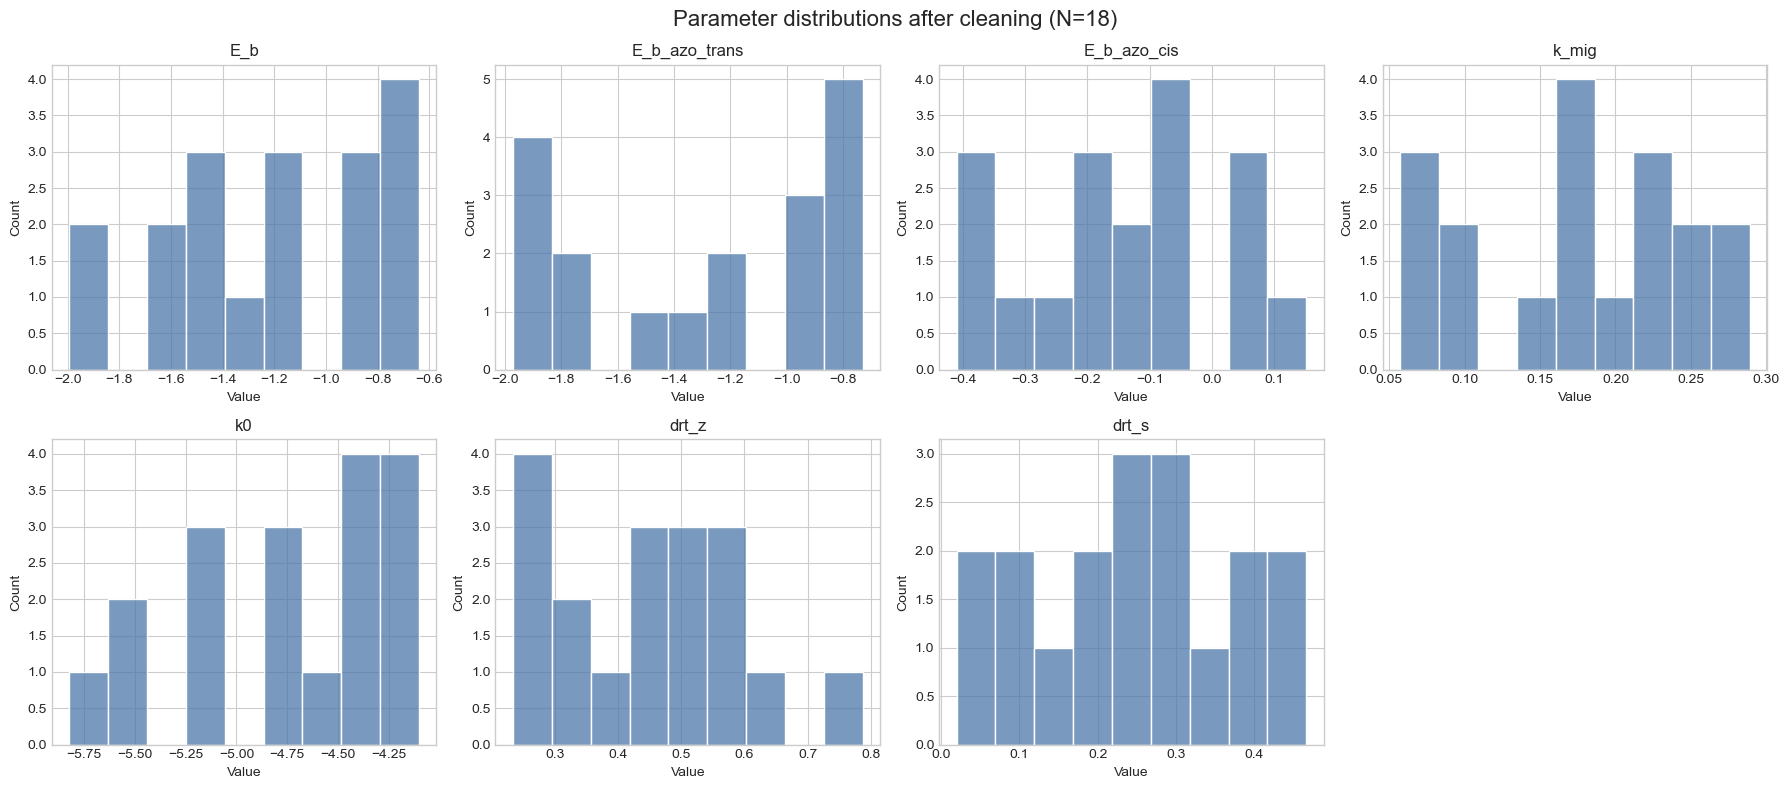

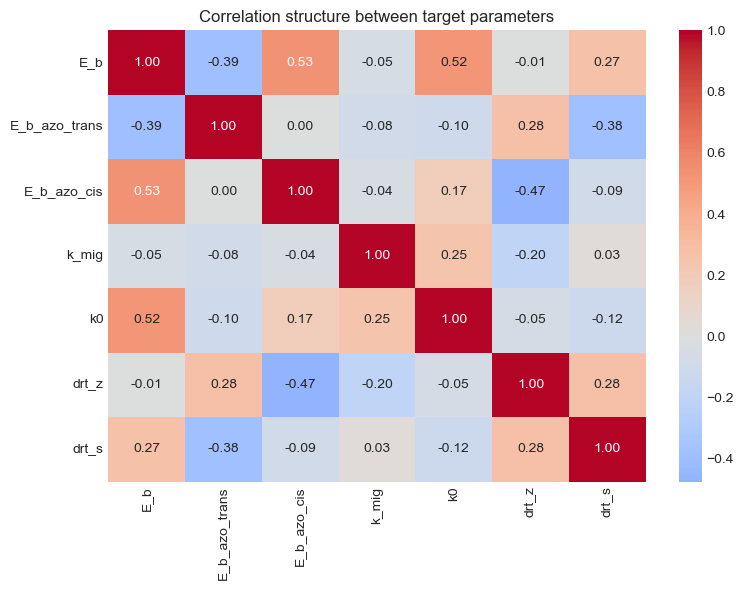

In [8]:
bins = min(30, max(6, len(Y_valid) // 2))

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, name in enumerate(param_names):
    sns.histplot(Y_valid[:, i], bins=bins, ax=axes[i], color='#4C78A8', edgecolor='white')
    axes[i].set_title(name)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count')

axes[-1].axis('off')
plt.suptitle(f'Parameter distributions after cleaning (N={len(Y_valid)})', fontsize=16)
plt.tight_layout()
plt.show()

corr_df = pd.DataFrame(Y_valid, columns=param_names)
fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr_df.corr(), cmap='coolwarm', center=0, annot=True, fmt='.2f', ax=ax)
ax.set_title('Correlation structure between target parameters')
plt.tight_layout()
plt.show()

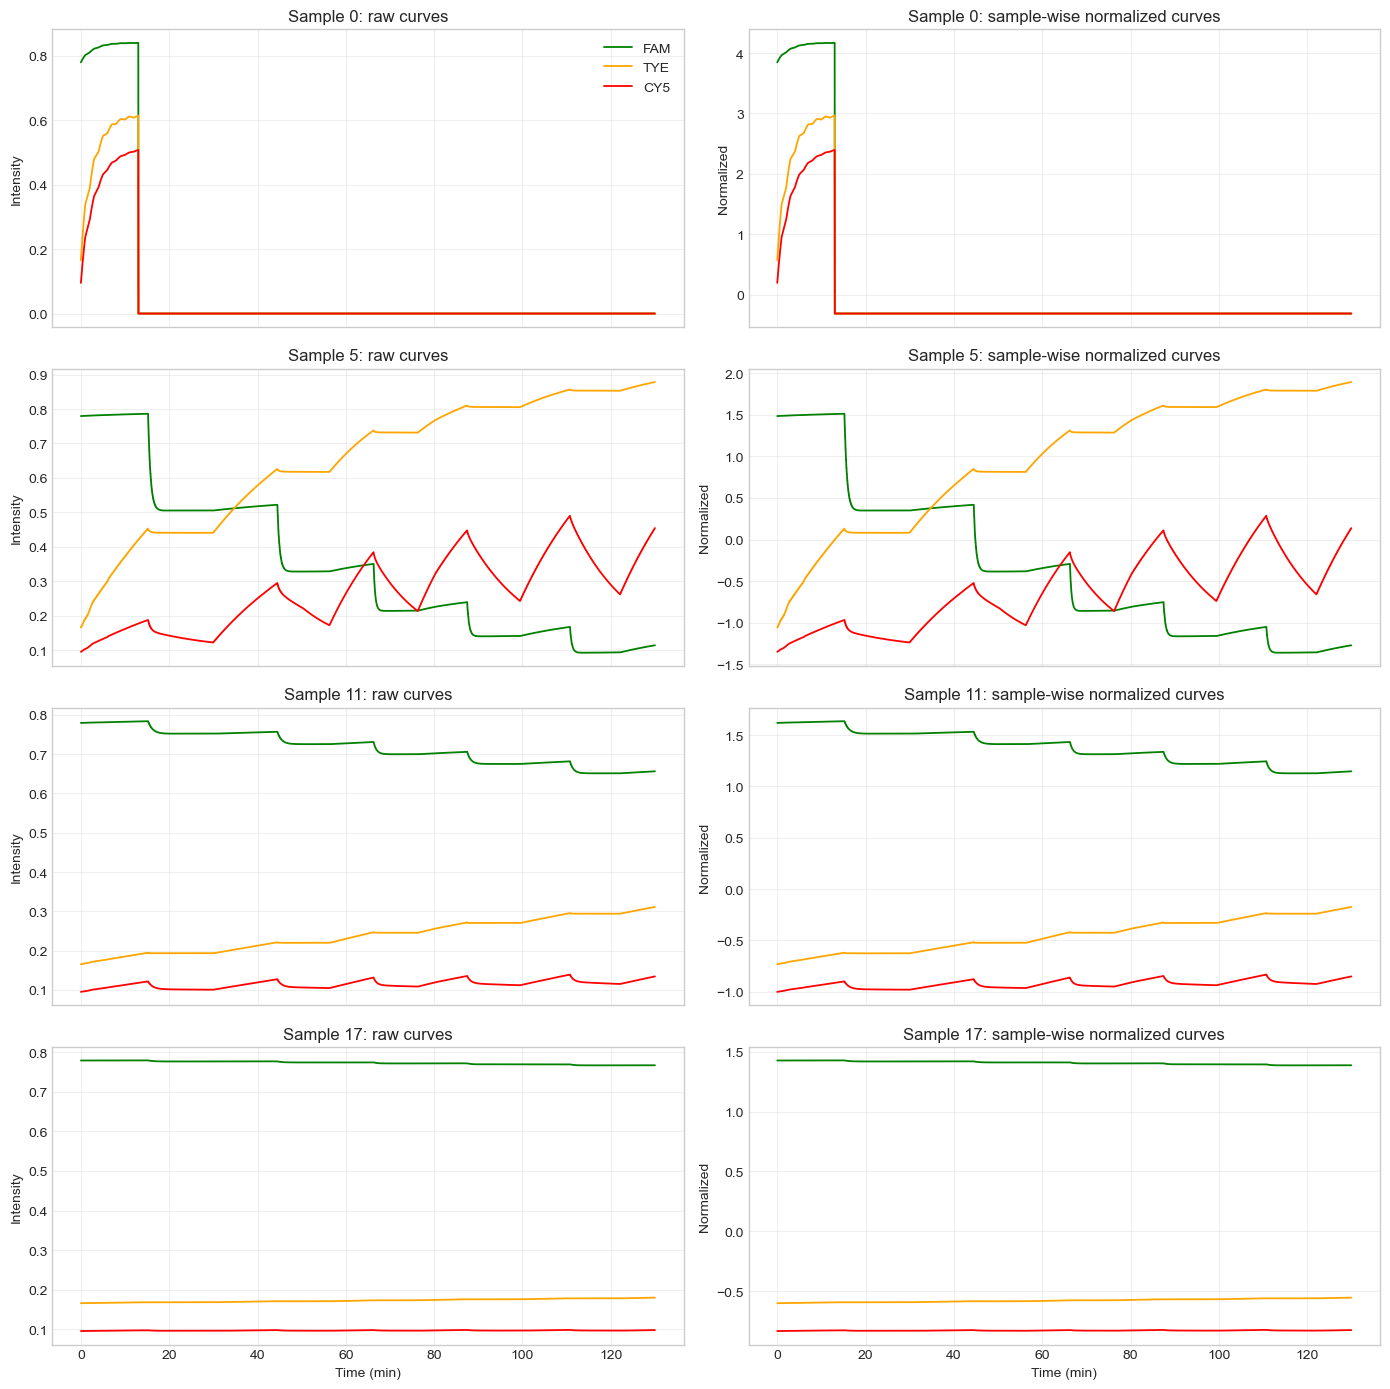

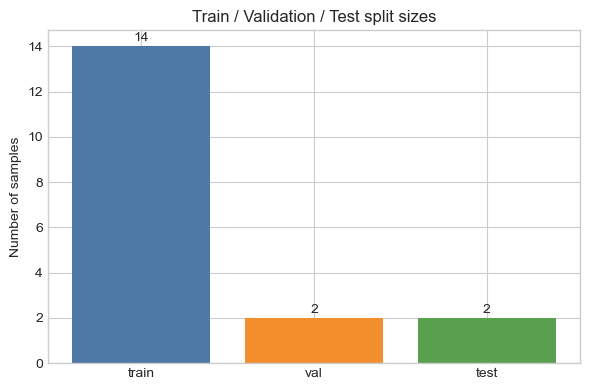

In [9]:
SAMPLES_TO_PLOT = min(4, len(X_valid_raw))
selected_indices = np.linspace(0, len(X_valid_raw) - 1, SAMPLES_TO_PLOT, dtype=int)
time_axis = np.linspace(0, parent_config.get_sim_duration_minutes(), X_valid_raw.shape[2])

fig, axes = plt.subplots(SAMPLES_TO_PLOT, 2, figsize=(14, 3.5 * SAMPLES_TO_PLOT), sharex='col')
if SAMPLES_TO_PLOT == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(selected_indices):
    ax_raw, ax_norm = axes[row]
    for ch, color, label in [(0, 'green', 'FAM'), (1, 'orange', 'TYE'), (2, 'red', 'CY5')]:
        ax_raw.plot(time_axis, X_valid_raw[idx, ch], color=color, linewidth=1.3, label=label if row == 0 else None)
        ax_norm.plot(time_axis, X_valid_3d[idx, ch], color=color, linewidth=1.3, label=label if row == 0 else None)

    ax_raw.set_title(f'Sample {idx}: raw curves')
    ax_norm.set_title(f'Sample {idx}: sample-wise normalized curves')
    ax_raw.set_ylabel('Intensity')
    ax_norm.set_ylabel('Normalized')
    ax_raw.grid(True, alpha=0.3)
    ax_norm.grid(True, alpha=0.3)

axes[0, 0].legend(loc='upper right')
axes[-1, 0].set_xlabel('Time (min)')
axes[-1, 1].set_xlabel('Time (min)')
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(split_counts.keys(), split_counts.values(), color=['#4E79A7', '#F28E2B', '#59A14F'])
ax.set_title('Train / Validation / Test split sizes')
ax.set_ylabel('Number of samples')
for x, y in enumerate(split_counts.values()):
    ax.text(x, y + 0.1, str(y), ha='center', va='bottom')
plt.tight_layout()
plt.show()

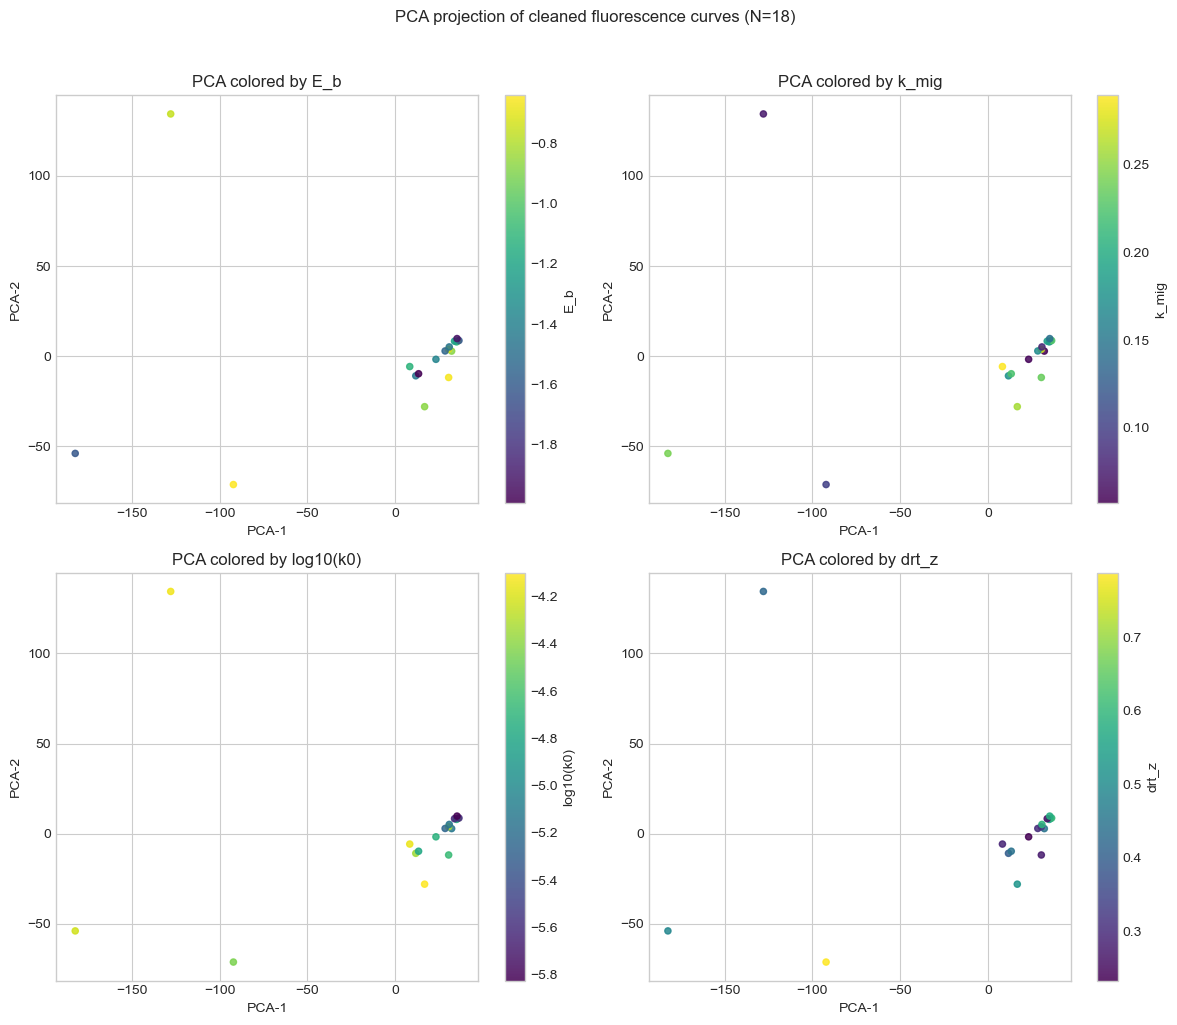

In [10]:
from sklearn.decomposition import PCA

selected_params_for_embedding = [
    ('E_b', 'E_b'),
    ('k_mig', 'k_mig'),
    ('log10(k0)', 'k0'),
    ('drt_z', 'drt_z'),
]

if len(X_valid_flat) < 3:
    print('Need at least 3 samples to draw a 2D embedding plot.')
else:
    if umap is not None and len(X_valid_flat) >= 100:
        reducer_name = 'UMAP'
        reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, n_components=2, random_state=42)
        embedding = reducer.fit_transform(X_valid_flat)
    else:
        reducer_name = 'PCA'
        reducer = PCA(n_components=2, random_state=42)
        embedding = reducer.fit_transform(X_valid_flat)

    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    for ax, (display_name, param_key) in zip(axes.flatten(), selected_params_for_embedding):
        idx = param_names.index(param_key)
        scatter = ax.scatter(
            embedding[:, 0],
            embedding[:, 1],
            c=Y_valid[:, idx],
            cmap='viridis',
            s=20 if len(embedding) < 500 else 4,
            alpha=0.85,
        )
        ax.set_title(f'{reducer_name} colored by {display_name}')
        ax.set_xlabel(f'{reducer_name}-1')
        ax.set_ylabel(f'{reducer_name}-2')
        plt.colorbar(scatter, ax=ax, label=display_name)

    plt.suptitle(f'{reducer_name} projection of cleaned fluorescence curves (N={len(embedding)})', y=1.02)
    plt.tight_layout()
    plt.show()

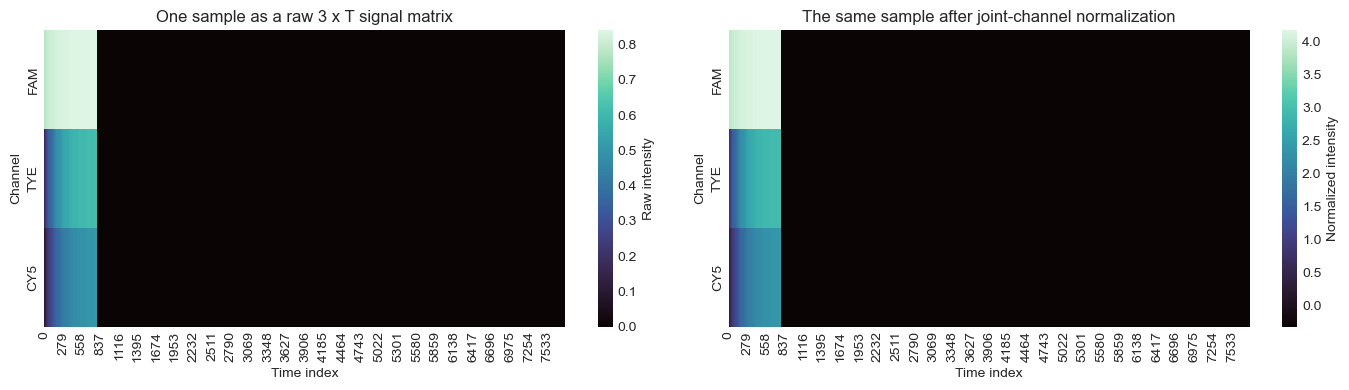

In [11]:
sample_id = 0

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.heatmap(X_valid_raw[sample_id], cmap='mako', ax=axes[0], cbar_kws={'label': 'Raw intensity'})
sns.heatmap(X_valid_3d[sample_id], cmap='mako', ax=axes[1], cbar_kws={'label': 'Normalized intensity'})

for ax, title in zip(
    axes,
    [
        'One sample as a raw 3 x T signal matrix',
        'The same sample after joint-channel normalization',
    ],
):
    ax.set_title(title)
    ax.set_xlabel('Time index')
    ax.set_ylabel('Channel')
    ax.set_yticks([0.5, 1.5, 2.5], labels=['FAM', 'TYE', 'CY5'])

plt.tight_layout()
plt.show()

These figures are diagnostic plots for checking data quality and preprocessing behavior.

## Step 3: Models and Added Features

Current implementations shown here: 1D-CNN inverse model, TokenMixer Transformer, and the ForwardDecoder / Digital Twin training flow.

,model,input shape,output shape,trainable params
0,1D-CNN inverse model,"(B, 23403)","(1, 7)",4381319
1,TokenMixer Transformer,"(B, 3, 7801)","(1, 7)",12299335
2,ForwardDecoder,"(B, 7)","(1, 23403)",8757283


C:\Users\GB\AppData\Local\Temp\ipykernel_1916\3327548694.py:59: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


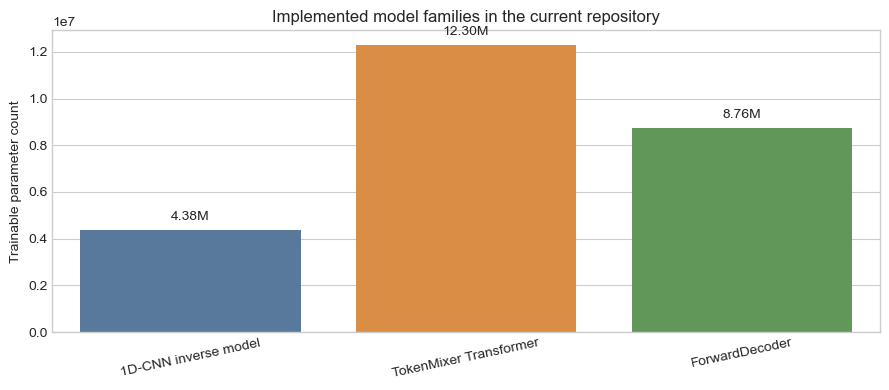

In [12]:
import sys
from pathlib import Path
import torch

ROOT = Path.cwd()
for extra_path in [ROOT, ROOT / 'train_cnn', ROOT / 'train_transformer']:
    extra_path = str(extra_path)
    if extra_path not in sys.path:
        sys.path.insert(0, extra_path)

from config_loader import Config
from model_cnn import InverseCNN, ForwardDecoder
from config_loader_transformer import load_configs
from model_transformer import build_transformer


def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


parent_config = Config('configfile.ini')
_, transformer_config = load_configs()

cnn_model = InverseCNN(parent_config.get_input_size(), parent_config.get_output_size(), parent_config).eval()
transformer_model = build_transformer(parent_config, transformer_config).eval()
decoder_model = ForwardDecoder(parent_config.get_output_size(), parent_config).eval()

with torch.no_grad():
    cnn_out = cnn_model(torch.tensor(X_valid_flat[:1], dtype=torch.float32))
    transformer_out = transformer_model(torch.tensor(X_valid_3d[:1], dtype=torch.float32))
    decoder_out = decoder_model(cnn_out)

model_comparison = pd.DataFrame(
    [
        {
            'model': '1D-CNN inverse model',
            'input shape': '(B, 23403)',
            'output shape': tuple(cnn_out.shape),
            'trainable params': count_parameters(cnn_model),
        },
        {
            'model': 'TokenMixer Transformer',
            'input shape': '(B, 3, 7801)',
            'output shape': tuple(transformer_out.shape),
            'trainable params': count_parameters(transformer_model),
        },
        {
            'model': 'ForwardDecoder',
            'input shape': '(B, 7)',
            'output shape': tuple(decoder_out.shape),
            'trainable params': count_parameters(decoder_model),
        },
    ]
)

display(model_comparison)

fig, ax = plt.subplots(figsize=(9, 4))
sns.barplot(
    data=model_comparison,
    x='model',
    y='trainable params',
    palette=['#4E79A7', '#F28E2B', '#59A14F'],
    ax=ax,
)
ax.set_title('Implemented model families in the current repository')
ax.set_ylabel('Trainable parameter count')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=12)
for patch, value in zip(ax.patches, model_comparison['trainable params']):
    ax.annotate(
        f'{value / 1e6:.2f}M',
        (patch.get_x() + patch.get_width() / 2, patch.get_height()),
        ha='center',
        va='bottom',
        xytext=(0, 5),
        textcoords='offset points',
    )
plt.tight_layout()
plt.show()

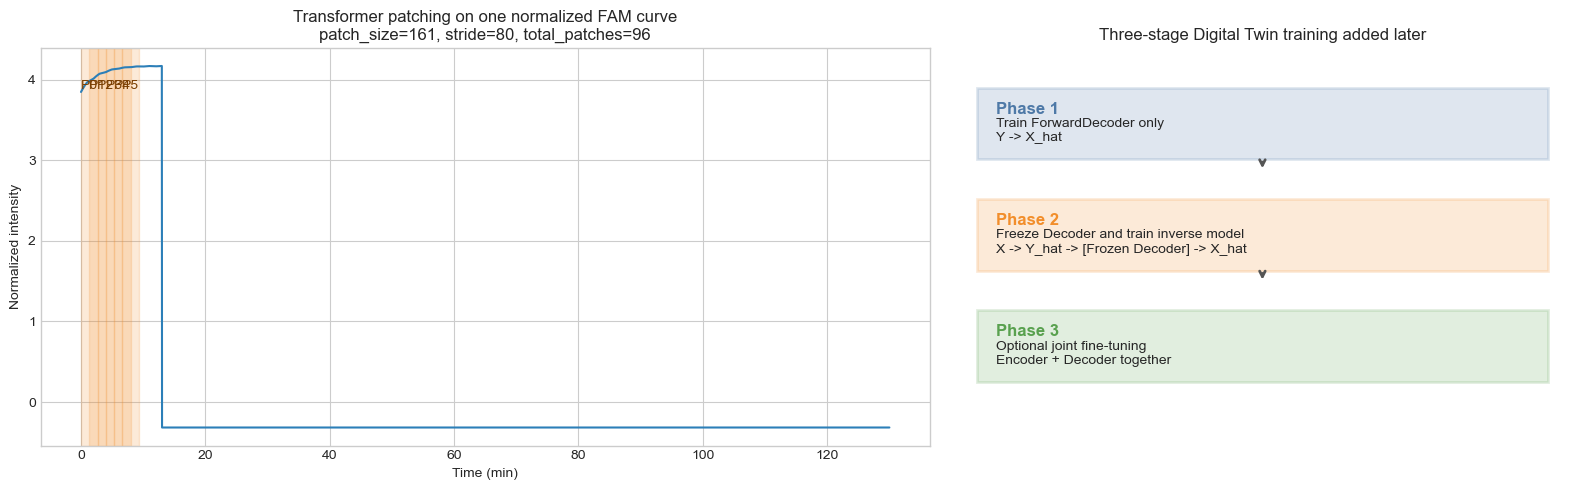

In [13]:
from matplotlib.patches import Rectangle

sample_id = 0
channel_id = 0
channel_name = ['FAM', 'TYE', 'CY5'][channel_id]
time_axis = np.linspace(0, parent_config.get_sim_duration_minutes(), X_valid_3d.shape[2])
patch_size = transformer_config.get_patch_size()
stride = transformer_config.get_stride()
num_patches = transformer_model.num_patches

fig = plt.figure(figsize=(16, 5))
grid = fig.add_gridspec(1, 2, width_ratios=[1.4, 1.0])

ax_curve = fig.add_subplot(grid[0, 0])
ax_curve.plot(time_axis, X_valid_3d[sample_id, channel_id], color='#2C7FB8', linewidth=1.5)
ymin, ymax = ax_curve.get_ylim()
for patch_id in range(min(6, num_patches)):
    start = patch_id * stride
    end = min(start + patch_size - 1, len(time_axis) - 1)
    ax_curve.axvspan(time_axis[start], time_axis[end], color='#F28E2B', alpha=0.18)
    ax_curve.text(
        (time_axis[start] + time_axis[end]) / 2,
        ymax - 0.08 * (ymax - ymin),
        f'P{patch_id}',
        ha='center',
        va='top',
        fontsize=10,
        color='#7A3E00',
    )
ax_curve.set_title(
    f'Transformer patching on one normalized {channel_name} curve\n'
    f'patch_size={patch_size}, stride={stride}, total_patches={num_patches}'
)
ax_curve.set_xlabel('Time (min)')
ax_curve.set_ylabel('Normalized intensity')

ax_flow = fig.add_subplot(grid[0, 1])
ax_flow.set_xlim(0, 1)
ax_flow.set_ylim(0, 1)
ax_flow.axis('off')
phases = [
    ('Phase 1', 'Train ForwardDecoder only\nY -> X_hat', '#4E79A7'),
    ('Phase 2', 'Freeze Decoder and train inverse model\nX -> Y_hat -> [Frozen Decoder] -> X_hat', '#F28E2B'),
    ('Phase 3', 'Optional joint fine-tuning\nEncoder + Decoder together', '#59A14F'),
]
for i, (title, desc, color) in enumerate(phases):
    y = 0.72 - i * 0.28
    rect = Rectangle((0.05, y), 0.9, 0.18, facecolor=color, edgecolor=color, alpha=0.18, linewidth=2)
    ax_flow.add_patch(rect)
    ax_flow.text(0.08, y + 0.115, title, fontsize=12, weight='bold', color=color)
    ax_flow.text(0.08, y + 0.045, desc, fontsize=10)
    if i < len(phases) - 1:
        ax_flow.annotate('', xy=(0.5, y - 0.03), xytext=(0.5, y), arrowprops=dict(arrowstyle='->', lw=2, color='#555555'))
ax_flow.set_title('Three-stage Digital Twin training added later')

plt.tight_layout()
plt.show()

<em>Notebook updated for concise visualization-first presentation.</em>